Problem
Hotel bookings get canceled, which causes revenue loss.

Goal:
Predict whether a booking will be canceled or not.

Target Variable
Is Canceled (Indicates whether the booking was ultimately canceled by the customer)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [4]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [5]:
import xgboost as xgb
import lightgbm as lgb

In [6]:
df = pd.read_csv('/kaggle/input/datasets/sanjeethpekumar/hotel-booking/hotel_bookings.csv')

In [7]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [8]:
df.shape

(119390, 32)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [10]:
missing = df.isnull().sum()
missing.sort_values(ascending = False).head(5)

company               112593
agent                  16340
country                  488
children                   4
arrival_date_month         0
dtype: int64

In [11]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [12]:
# Data Cleaning

In [13]:
# since the company and agent columns has large number of missing value should be dropped (useless columns)

In [14]:
df.drop(columns = ['company','agent'],inplace = True)

In [15]:
df['children'].fillna(0,inplace = True)

In [16]:
df['country'].fillna('unknown',inplace = True)

In [17]:
df.isnull().sum().sort_values(ascending = False).head(5)

hotel                 0
is_canceled           0
lead_time             0
arrival_date_year     0
arrival_date_month    0
dtype: int64

In [18]:
df.shape

(119390, 30)

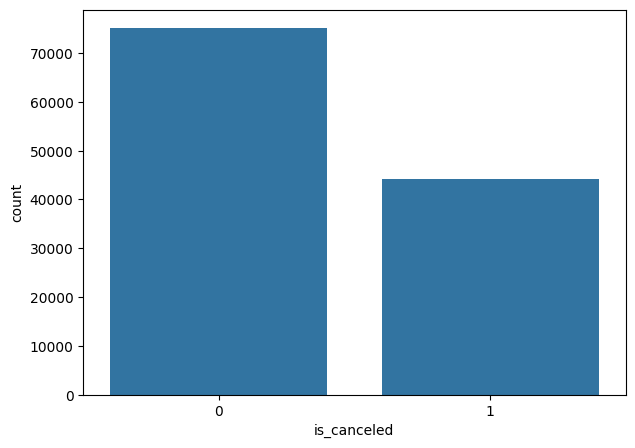

In [19]:
plt.figure(figsize = (7,5))
sns.countplot(x = 'is_canceled',data = df)
plt.show()

In [20]:
(df['is_canceled'].value_counts(normalize = True)*100).round(2)

is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64

In [21]:
# 63% is not canceled and 37% canceled the booking so data is imbalance

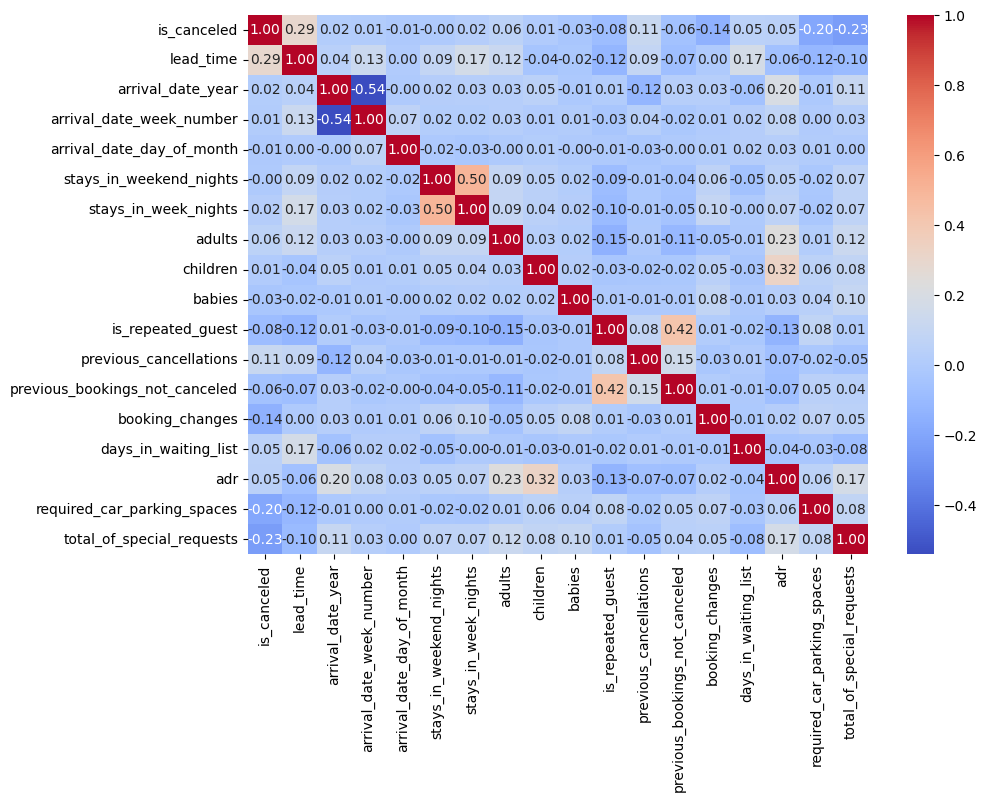

In [22]:
plt.figure(figsize = (10,7))
sns.heatmap(df.corr(numeric_only = True),annot = True,cmap = 'coolwarm',fmt = '.2f')
plt.show()

In [23]:
# Feature Engineering

In [24]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [25]:

df['total_guest'] = df['adults']+df['children']+df['babies']

In [26]:
df['total_nights'] = df['stays_in_weekend_nights']+df['stays_in_week_nights']

In [27]:
df['booking_change_flag'] = df['booking_changes'].apply(lambda x: 1 if x>0 else 0)

In [28]:
df['waiting_flag'] = df['days_in_waiting_list'].apply(lambda x: 1 if x>0 else 0)

In [29]:
df.shape

(119390, 34)

In [30]:
df.drop(columns = ['adults','children','babies','days_in_waiting_list','booking_changes','stays_in_weekend_nights',
                  'stays_in_week_nights'],axis = 1,
       inplace = True)

In [31]:
df.drop(["reservation_status","reservation_status_date"], axis=1, inplace=True)

In [32]:
df.shape

(119390, 25)

In [33]:
X = df.drop(['is_canceled'],axis = 1)
y = df['is_canceled']

In [34]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)

In [35]:
num_cols = X.select_dtypes(include = ['int','float']).columns
cat_cols = X.select_dtypes(include = ['object']).columns

In [36]:
print('Num_Cols:',num_cols)
print('Cat_Cols:',cat_cols)

Num_Cols: Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guest', 'total_nights', 'booking_change_flag', 'waiting_flag'],
      dtype='object')
Cat_Cols: Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object')


In [37]:
num_pipeline = Pipeline([('scaler',StandardScaler())])

In [38]:
cat_pipeline = Pipeline([('encoder',OneHotEncoder(handle_unknown = 'ignore'))])

In [39]:
preprocessor = ColumnTransformer([('num',num_pipeline,num_cols),('cat',cat_pipeline,cat_cols)])

In [40]:
baseline_model = Pipeline([('preprocessor',preprocessor),('model',LogisticRegression(max_iter = 1000))])

In [41]:
baseline_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guest', 'total_nights', 'booking_change_flag', 'waiting_flag'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [42]:
y_pred = baseline_model.predict(x_test)

In [43]:
accuracy = accuracy_score(y_test,y_pred)

In [44]:
print(accuracy)

0.8191640840941452


In [45]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[13655  1378]
 [ 2940  5905]]


In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86     15033
           1       0.81      0.67      0.73      8845

    accuracy                           0.82     23878
   macro avg       0.82      0.79      0.80     23878
weighted avg       0.82      0.82      0.81     23878



In [47]:
rf_model = Pipeline([('preprocessor',preprocessor),('model',RandomForestClassifier(n_estimators = 200,max_depth = 10,random_state = 42))])

In [48]:
rf_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
       'required_car_parking_spaces', 'total_of_special_request...
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        random_state=42))])

In [49]:
rf_pred = rf_model.predict(x_test)

In [50]:
accuracy = accuracy_score(y_test,rf_pred)
print(accuracy)

0.7822681966663875


In [51]:
print(confusion_matrix(y_test,rf_pred))

[[14968    65]
 [ 5134  3711]]


In [52]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85     15033
           1       0.98      0.42      0.59      8845

    accuracy                           0.78     23878
   macro avg       0.86      0.71      0.72     23878
weighted avg       0.83      0.78      0.75     23878



In [53]:
#XGBClassifier Model


In [54]:
xgb_model = Pipeline([('preprocessor',preprocessor),('model',xgb.XGBClassifier(n_estimators = 200,max_depth = 10,learning_rate = 0.05,
                                                                              random_state = 42))])

In [55]:
xgb_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
       'required_car_parking_spaces', 'total_of_special_request...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=10, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [56]:
xgb_pred = xgb_model.predict(x_test)

In [57]:
accuracy = accuracy_score(y_test,xgb_pred)
print(accuracy)

0.8725605159561102


In [58]:
print(confusion_matrix(y_test,xgb_pred))

[[13880  1153]
 [ 1890  6955]]


In [59]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90     15033
           1       0.86      0.79      0.82      8845

    accuracy                           0.87     23878
   macro avg       0.87      0.85      0.86     23878
weighted avg       0.87      0.87      0.87     23878



In [60]:
y_prob = xgb_model.predict_proba(x_test)[:,1]
roc_score = roc_auc_score(y_test,y_prob)
print(roc_score)

0.9478096444840381


In [61]:
# Model Comparison
print("Logistic:", accuracy_score(y_test, y_pred))
print("RandomForest:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))

Logistic: 0.8191640840941452
RandomForest: 0.7822681966663875
XGBoost: 0.8725605159561102


In [62]:
from sklearn.model_selection import cross_val_score

In [63]:
cv_scores = cross_val_score(xgb_model,X,y,cv = 5,scoring = 'accuracy')

In [64]:
print('cv_scores:',cv_scores)
print('cv_scores_mean:',cv_scores.mean())

cv_scores: [0.6202362  0.52391323 0.41933998 0.40572912 0.52177737]
cv_scores_mean: 0.4981991791607337


In [65]:
model = xgb_model.named_steps['model']
importances = model.feature_importances_
features = xgb_model.named_steps['preprocessor'].get_feature_names_out()
feat_imp = pd.DataFrame({'feature': features,'importance':importances}).sort_values(by = 'importance',ascending = False)
feat_imp.head(10)


,feature,importance
242,cat__deposit_type_Non Refund,0.542987
212,cat__market_segment_Online TA,0.067076
8,num__required_car_parking_spaces,0.042702
163,cat__country_PRT,0.027606
5,num__previous_cancellations,0.016590
9,num__total_of_special_requests,0.013323
246,cat__customer_type_Transient,0.010320
219,cat__reserved_room_type_A,0.009056
209,cat__market_segment_Direct,0.008433
12,num__booking_change_flag,0.008033


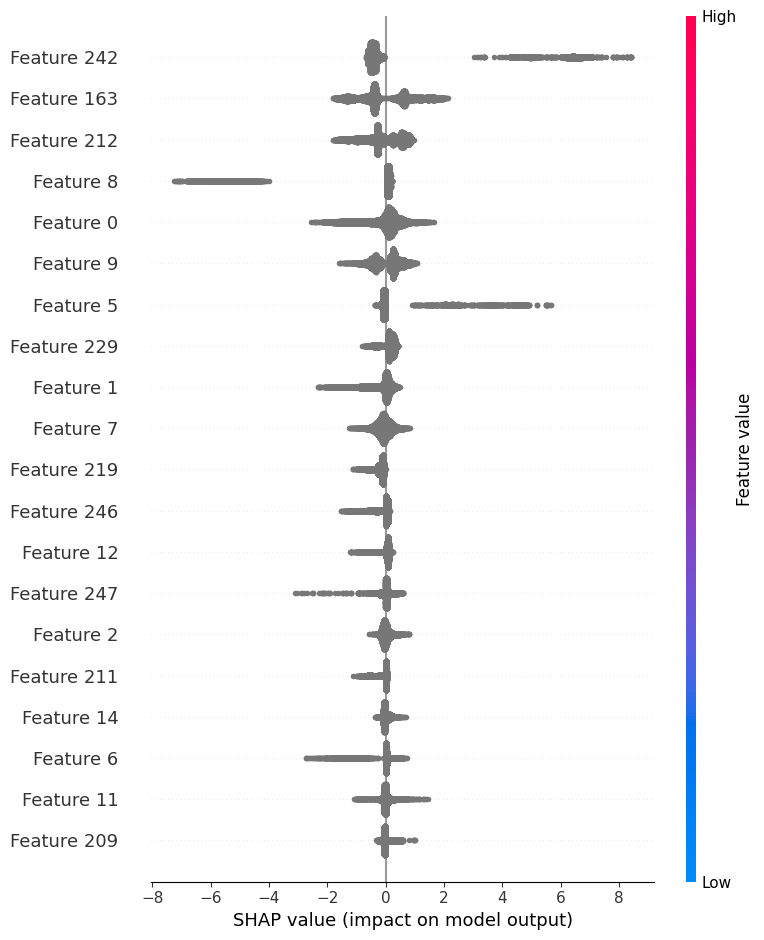

In [66]:
import shap

# Extract trained model from pipeline
model = xgb_model.named_steps["model"]

# Transform data
X_transformed = xgb_model.named_steps["preprocessor"].transform(x_test)

# Create explainer
explainer = shap.TreeExplainer(model)

# SHAP values
shap_values = explainer.shap_values(X_transformed)

# Plot
shap.summary_plot(shap_values, X_transformed)

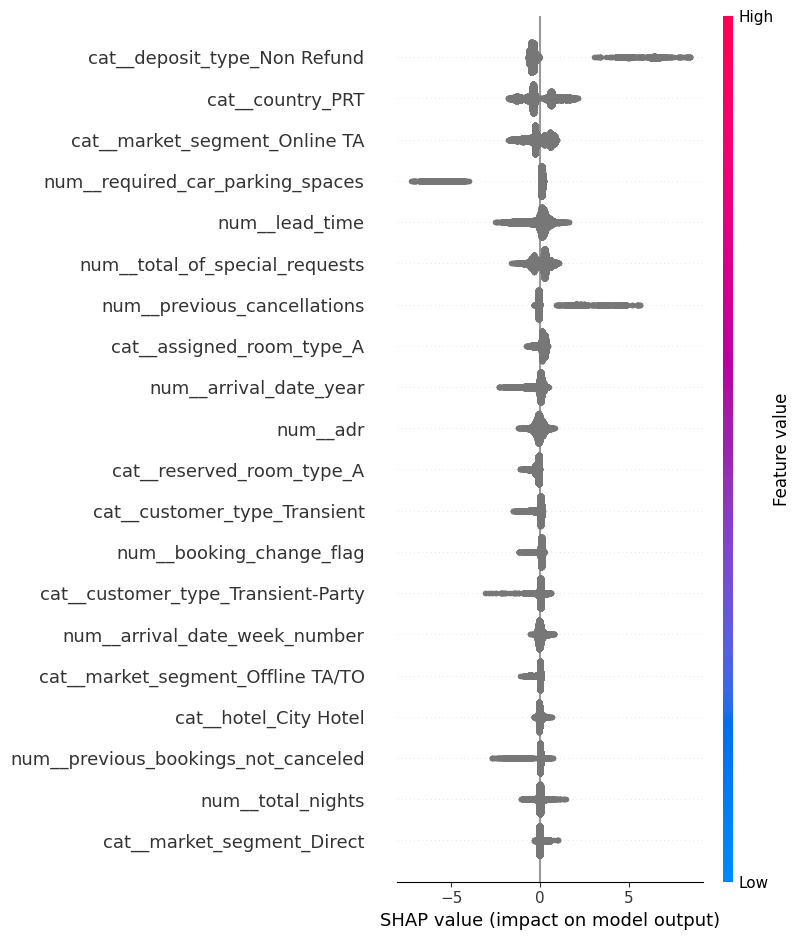

In [67]:
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

Using SHAP analysis, I found that:

- Lead time and previous cancellations strongly increase cancellation risk
- Customers with more special requests and parking requirements are less likely to cancel
- Online travel agents and non-refundable bookings show higher cancellation probability

In [68]:
errors = x_test[y_test != xgb_pred]

errors.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,meal,country,market_segment,distribution_channel,...,assigned_room_type,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guest,total_nights,booking_change_flag,waiting_flag
48445,City Hotel,82,2016,March,13,23,BB,ESP,Online TA,TA/TO,...,F,No Deposit,Transient,158.83,0,0,4.0,4,0,0
68857,City Hotel,29,2017,May,21,21,BB,BRA,Online TA,TA/TO,...,D,No Deposit,Transient,190.00,0,4,2.0,7,0,0
110682,City Hotel,110,2017,April,17,28,BB,IRL,Online TA,TA/TO,...,D,No Deposit,Transient,166.50,0,0,3.0,3,0,0
73629,City Hotel,35,2017,August,35,28,BB,GBR,Online TA,TA/TO,...,D,No Deposit,Transient,170.00,0,1,2.0,4,0,0
60040,City Hotel,121,2016,November,45,4,BB,ITA,Online TA,TA/TO,...,D,No Deposit,Transient,122.40,0,1,3.0,3,0,0


In [69]:
errors.shape

(3043, 24)

In [70]:
from sklearn.model_selection import GridSearchCV

In [78]:
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.01, 0.05],
    "model__subsample": [0.8, 1],
    "model__colsample_bytree": [0.8, 1]
}

In [79]:
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

In [80]:
grid.fit(x_train,y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
       'required_car_parking_space...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=200,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1],
                         'model__learning_rate': [0.01, 0.05],
                         'model__max_depth': [4, 6, 8],
                         'model__n_estimators': [200, 300],
                         'model__subsample': [0.8, 1]},
             scoring='accuracy', verbose=2)

In [81]:
print("Best Params:", grid.best_params_)

Best Params: {'model__colsample_bytree': 1, 'model__learning_rate': 0.05, 'model__max_depth': 8, 'model__n_estimators': 300, 'model__subsample': 0.8}


In [83]:
best_model = grid.best_estimator_

In [84]:
y_pred_tuned = best_model.predict(x_test)

In [87]:
accuracy_best_model = accuracy_score(y_test,y_pred_tuned)

In [88]:
print(accuracy_best_model)

0.8745288550129826
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=4, model__n_estimators=200, model__subsample=1; total time=   2.9s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=4, model__n_estimators=300, model__subsample=0.8; total time=   3.9s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=4, model__n_estimators=300, model__subsample=1; total time=   3.8s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=6, model__n_estimators=200, model__subsample=0.8; total time=   3.8s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=6, model__n_estimators=300, model__subsample=0.8; total time=   5.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=6, model__n_estimators=300, model__subsample=1; total time=   5.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth

In [90]:
print("Train Score:", best_model.score(x_train, y_train))
print("Test Score:", best_model.score(x_test, y_test))

Train Score: 0.8879407823100762
Test Score: 0.8745288550129826


In [91]:
import pickle

pickle.dump(best_model, open("hotel_model.pkl", "wb"))